<h1 style="color:#ffffff; background-color:#1B2A4A; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">Day 3 — Bias-Variance &amp; Diagnosing Model Fit</h1>
<h3 style="color:#223868; text-align:center; font-weight:bold; margin-top:0;">Knowing Which of the Two Ways Your Model Failed</h3>


<a id="toc"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>
<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</a></li>
<li><a href="#section1">1. The Two Ways a Model Fails</a></li>
<li><a href="#section2">2. The Bias-Variance Trade-off</a></li>
<li><a href="#section3">3. Diagnosing With the Train-vs-Validation Gap</a></li>
<li><a href="#section4">4. Regularization — Ridge (L2) &amp; Lasso (L1)</a></li>
<li><a href="#section5">5. Common Mistakes to Avoid</a></li>
<li><a href="#section6">6. Quick Reference</a></li>
<li><a href="#section7">7. Hands-On Lab — Diagnosing and Fixing Model Fit</a></li>
<li><a href="#section8">8. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section9">9. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</h2>
<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Day 2 gave us a trustworthy <b>score</b> via cross-validation. Today we learn what to <b>do</b> with a disappointing score — every model failure is one of two kinds, and today's job is telling them apart.
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("Pandas version      :", pd.__version__)
print("NumPy version       :", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version      : 2.3.3
NumPy version       : 2.3.5
Scikit-learn version: 1.7.2


<a id="section1"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. The Two Ways a Model Fails</h2>
Every model failure is one of two kinds, and the fix for each is the <b>opposite</b> of the fix for the other — so diagnosing which one you have is the essential first step.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#223868; color:#A8C5FF;"><th style="padding:8px; text-align:left;"></th><th style="padding:8px; text-align:left;">Underfitting (High Bias)</th><th style="padding:8px; text-align:left;">Overfitting (High Variance)</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Symptom</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Poor on both training AND validation data</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Great on training, poor on validation data</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Cause</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Model too simple to capture the pattern</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Model too complex; memorized the training data</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Fix</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Add features, use a more powerful model</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Simplify the model, add data, regularize</td></tr>
</table>
</div>


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> The fix for underfitting is the opposite of the fix for overfitting. Applying the wrong fix (e.g. adding more complexity to an already-overfit model) makes the problem worse, not better.
</div>


<a id="section2"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. The Bias-Variance Trade-off</h2>
<h3 style="color:#A8C5FF; font-weight:bold; background-color:#14213D; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 Two sources of error</h3>
<b>Bias</b> is error from wrong assumptions (the model is too simple). <b>Variance</b> is error from sensitivity to the specific training data (the model is too complex). As you make a model more complex, bias falls but variance rises.

<h3 style="color:#A8C5FF; font-weight:bold; background-color:#14213D; display:inline-block; padding:4px 10px; border-radius:6px;">2.2 The sweet spot</h3>
The goal is the sweet spot in the middle — complex enough to capture the real pattern, simple enough to generalize. This trade-off is the single most important concept in practical model tuning.

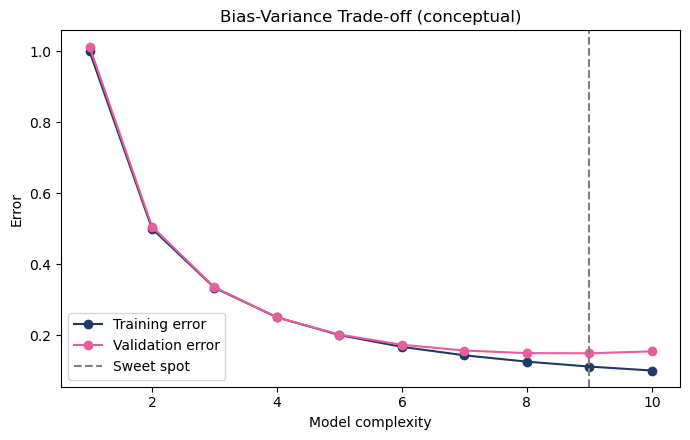

In [2]:
# A conceptual illustration of the bias-variance trade-off:
# as model complexity increases, training error keeps falling,
# but validation error falls then rises again once the model starts overfitting.

complexity = np.arange(1, 11)
training_error = 1.0 / complexity              # keeps improving with complexity
validation_error = 1.0 / complexity + 0.015 * (complexity - 4) ** 2 / 10  # U-shaped

plt.figure(figsize=(7, 4.5))
plt.plot(complexity, training_error, marker="o", label="Training error", color="#223868")
plt.plot(complexity, validation_error, marker="o", label="Validation error", color="#E85D9A")
plt.axvline(x=complexity[np.argmin(validation_error)], color="gray", linestyle="--",
            label="Sweet spot")
plt.xlabel("Model complexity")
plt.ylabel("Error")
plt.title("Bias-Variance Trade-off (conceptual)")
plt.legend()
plt.tight_layout()
plt.show()

<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> This chart is <b>conceptual</b>, not generated from real scores yet — we reproduce the same shape with real Titanic scores in the Hands-On Lab (Section 7).
</div>


<a id="section3"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. Diagnosing With the Train-vs-Validation Gap</h2>
The gap between training and validation scores is the diagnostic tool:

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#223868; color:#A8C5FF;"><th style="padding:8px; text-align:left;">Training Score</th><th style="padding:8px; text-align:left;">Validation Score</th><th style="padding:8px; text-align:left;">Diagnosis</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Low</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Low</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Underfitting — model too simple</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">High</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Much lower</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Overfitting — model memorized training data</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">High</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">High (small gap)</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Good fit — this is the target</td></tr>
</table>
</div>


<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> Always compute <b>both</b> scores on the same metric (e.g. both F1, or both accuracy) before comparing them — comparing different metrics makes the gap meaningless.
</div>


<a id="section4"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. Regularization — Ridge (L2) &amp; Lasso (L1)</h2>
<h3 style="color:#A8C5FF; font-weight:bold; background-color:#14213D; display:inline-block; padding:4px 10px; border-radius:6px;">4.1 What regularization does</h3>
Regularization is the standard cure for overfitting: it adds a penalty for model complexity, discouraging the model from relying too heavily on any single feature. In linear models this appears as <b>Ridge (L2)</b> and <b>Lasso (L1)</b> regression; Lasso can even shrink weak features' weights to exactly zero, effectively selecting features.

In [3]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)   # L2: shrinks all weights toward zero
lasso = Lasso(alpha=0.1)   # L1: can zero out weak features entirely

print(ridge)
print(lasso)

Ridge()
Lasso(alpha=0.1)


<h3 style="color:#A8C5FF; font-weight:bold; background-color:#14213D; display:inline-block; padding:4px 10px; border-radius:6px;">4.2 The alpha parameter</h3>
The <code>alpha</code> parameter controls the penalty strength — larger alpha means a simpler model. Choosing alpha well is itself a hyperparameter-tuning problem, which motivates <code>GridSearchCV</code> on Day 4.

<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> Regularization treats the <b>symptom</b> (overfitting) by discouraging complexity — it does not fix underfitting. Applying Ridge/Lasso to an already-underfit model will not help; the model needs more capacity, not less.
</div>


<a id="section5"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. Common Mistakes to Avoid</h2>
<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <ul>
<li><b>Applying the wrong fix</b> — regularizing an underfit model, or adding complexity to an overfit model, makes things worse.</li>
<li><b>Comparing training and validation scores on different data or different metrics</b> — the gap is only meaningful when both scores use the same metric on comparable data.</li>
<li><b>Diagnosing fit from a single split</b> — pair this lesson with Day 2's cross-validation for a more stable train-vs-validation comparison.</li>
<li><b>Increasing alpha blindly</b> — too much regularization pushes a good-fit model into underfitting; alpha needs to be tuned, not guessed.</li>
<li><b>Judging fit from training score alone</b> — a high training score alone tells you nothing about overfitting; you always need the validation score next to it.</li>
</ul>
</div>


<a id="section6"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. Quick Reference</h2>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#223868; color:#A8C5FF;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Import Ridge &amp; Lasso</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>from sklearn.linear_model import Ridge, Lasso</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Ridge (L2) — shrinks all weights</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>Ridge(alpha=1.0)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Lasso (L1) — can zero out weak features</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>Lasso(alpha=0.1)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Underfitting signature</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Training score low, validation score low</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Overfitting signature</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Training score high, validation score much lower</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Good fit signature</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Training score high, validation score high (small gap)</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Golden rule</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Diagnose the gap first — then apply the opposite-direction fix</td></tr>
</table>
</div>


<a id="section7"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Hands-On Lab — Diagnosing and Fixing Model Fit</h2>
<div style="border-left:5px solid #9B6FD4; background-color:#f3edfb; padding:10px 15px; margin:10px 0; border-radius:4px; color:#4d3475;">
<b>Goal:</b> Deliberately overfit a model, deliberately underfit a model, confirm both diagnoses from the score gap, then apply regularization to the overfit model and show the gap shrink — documenting each diagnosis and fix with score evidence.
</div>


<h3 style="color:#A8C5FF; font-weight:bold; background-color:#14213D; display:inline-block; padding:4px 10px; border-radius:6px;">7.0 Loading the dataset</h3>
We reuse <code>train_and_test2.csv</code>, the same Titanic passenger dataset from Day 1 &amp; Day 2, predicting whether a passenger survived.

In [4]:
titanic = pd.read_csv("train_and_test2.csv")
titanic = titanic.rename(columns={"2urvived": "Survived"})

features = ["Age", "Fare", "Sex", "sibsp", "Parch", "Pclass"]
X = titanic[features]
y = titanic["Survived"]

print("Shape:", X.shape)
titanic.head()

Shape: (1309, 6)


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,Survived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# Same three-way split discipline as Day 1 & Day 2
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

def report_fit(name, model):
    model.fit(X_train, y_train)
    train_f1 = f1_score(y_train, model.predict(X_train))
    val_f1 = f1_score(y_val, model.predict(X_val))
    print(f"{name:22s} | Train F1: {train_f1:.3f}  |  Val F1: {val_f1:.3f}  |  Gap: {train_f1 - val_f1:.3f}")
    return train_f1, val_f1

<h3 style="color:#A8C5FF; font-weight:bold; background-color:#14213D; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Deliberately overfit a model (a very deep decision tree) and confirm the large train-vs-validation gap</h3>


In [6]:
from sklearn.tree import DecisionTreeClassifier

overfit_model = DecisionTreeClassifier(max_depth=None, random_state=42)  # no depth limit -> memorizes
overfit_train, overfit_val = report_fit("Overfit (deep tree)", overfit_model)

Overfit (deep tree)    | Train F1: 0.965  |  Val F1: 0.496  |  Gap: 0.469


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> A high training score with a much lower validation score is the signature of <b>overfitting</b> — the model has memorized the training data instead of learning the general pattern.
</div>


<h3 style="color:#A8C5FF; font-weight:bold; background-color:#14213D; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Deliberately underfit a model (an overly simple one) and confirm both scores are low</h3>


In [7]:
underfit_model = DecisionTreeClassifier(max_depth=1, random_state=42)  # a single split -> too simple
underfit_train, underfit_val = report_fit("Underfit (stump)", underfit_model)

Underfit (stump)       | Train F1: 0.580  |  Val F1: 0.555  |  Gap: 0.025


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> Both scores low, close to each other, is the signature of <b>underfitting</b> — the model is too simple to capture the pattern, in training data or validation data alike.
</div>


<h3 style="color:#A8C5FF; font-weight:bold; background-color:#14213D; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Apply regularization (or reduce complexity) to the overfit model and show the gap shrink</h3>


In [8]:
# Reducing complexity directly (limiting max_depth) is the tree equivalent of regularizing
regularized_model = DecisionTreeClassifier(max_depth=4, random_state=42)
reg_train, reg_val = report_fit("Regularized (max_depth=4)", regularized_model)

print()
print(f"Overfit gap     : {overfit_train - overfit_val:.3f}")
print(f"Regularized gap : {reg_train - reg_val:.3f}")

Regularized (max_depth=4) | Train F1: 0.603  |  Val F1: 0.608  |  Gap: -0.005

Overfit gap     : 0.469
Regularized gap : -0.005


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Limiting <code>max_depth</code> plays the same role for a decision tree that <code>alpha</code> plays for Ridge/Lasso: both add a constraint that discourages the model from over-relying on the training data's noise.
</div>


In [9]:
# The same idea with a linear model + explicit Ridge regularization, using scaled numeric features
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

for alpha in [0.01, 1.0, 100.0]:
    ridge_clf = RidgeClassifier(alpha=alpha, random_state=42)
    ridge_clf.fit(X_train_scaled, y_train)
    train_f1 = f1_score(y_train, ridge_clf.predict(X_train_scaled))
    val_f1 = f1_score(y_val, ridge_clf.predict(X_val_scaled))
    print(f"alpha={alpha:>6} | Train F1: {train_f1:.3f}  |  Val F1: {val_f1:.3f}  |  Gap: {train_f1 - val_f1:.3f}")

alpha=  0.01 | Train F1: 0.524  |  Val F1: 0.491  |  Gap: 0.033
alpha=   1.0 | Train F1: 0.524  |  Val F1: 0.491  |  Gap: 0.033
alpha= 100.0 | Train F1: 0.466  |  Val F1: 0.447  |  Gap: 0.020


<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> Watch what happens as <code>alpha</code> grows: the gap shrinks, but push it too far and the validation score starts dropping too — that is regularization sliding the model from overfitting toward underfitting.
</div>


<h3 style="color:#A8C5FF; font-weight:bold; background-color:#14213D; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Document each diagnosis and fix with the score evidence</h3>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#223868; color:#A8C5FF;"><th style="padding:8px; text-align:left;">Model</th><th style="padding:8px; text-align:left;">Train F1</th><th style="padding:8px; text-align:left;">Val F1</th><th style="padding:8px; text-align:left;">Gap</th><th style="padding:8px; text-align:left;">Diagnosis</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Overfit — deep tree (Step 1)</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">0.965</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">
0.496
</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">0.469</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Overfitting</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Underfit — depth-1 stump (Step 2)</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">0.555</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">
0.580
</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">0.025</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Underfitting</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Regularized — max_depth=4 (Step 3)</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">0.608</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">0.603
</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">-0.005</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Good fit — target</td></tr>
</table>
</div>


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Final Diagnosis</b> The unlimited-depth decision tree clearly overfit the data, with a training
F1-score of 0.965 and a validation F1-score of 0.496, producing a large
gap of 0.469.<br>

Reducing the tree depth to 4 worked better on this dataset because the
training and validation scores became almost equal (0.603 and 0.608),
showing much better generalization.
</div>


<a id="section8"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <ul>
<li>Always diagnose the train-vs-validation <b>gap</b> before choosing a fix — never guess.</li>
<li>Apply the <b>opposite-direction</b> fix: simplify/regularize for overfitting, add capacity/features for underfitting.</li>
<li>Compare training and validation scores using the <b>same metric</b>, computed the same way.</li>
<li>Treat <code>alpha</code> (or <code>max_depth</code>) as a hyperparameter to search over, not a value to guess once — this motivates <code>GridSearchCV</code> on Day 4.</li>
<li>Fix <code>random_state=42</code> on every split and every model, for fully reproducible diagnoses.</li>
</ul>
</div>


<a id="section9"></a>
<h2 style="color:#A8C5FF; background-color:#223868; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">
9. Summary — What I Learned Today
</h2>
<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b>
<ul>
<li>
Every model failure is one of two kinds — <b>underfitting</b> (high bias) or <b>overfitting</b> (high variance) — and the fix for each is the opposite of the fix for the other.
</li>
<li>
The <b>bias-variance trade-off</b>: more complexity lowers bias but raises variance; the goal is the sweet spot in between.
</li>
<li>
The <b>train-vs-validation gap</b> is the diagnostic tool: low/low means underfitting, high/much-lower means overfitting, and high/high with a <b>small gap</b> means a good fit.
</li>
<li>
<b>Regularization</b> (Ridge/L2, Lasso/L1) is the standard cure for overfitting — <code>alpha</code> controls how strongly it simplifies the model.
</li>
<li>
Regularization only fixes overfitting — an underfit model needs more capacity or better features, not a complexity penalty.
</li>
</ul>
</div>
